# HeatGuard — Validation & Demo

**Adaptive WBGT-driven work-rest-hydration scheduling for outdoor labour crews in the Gulf.**

Every Gulf state runs a *calendar-based* midday work ban (Saudi: 12:00–15:00, 15 Jun–15 Sep).
It ignores actual conditions, work intensity, and acclimatization. HeatGuard replaces it with a
condition-responsive schedule built on published standards — ISO 7243 / ACGIH work-rest tables and
the ISO 7933 Predicted Heat Strain model (`pythermalcomfort`) — plus a tamper-evident audit trail
and an impact estimator grounded in the La Isla / Adelante (Nicaragua) effect sizes.

This notebook validates the engine and reproduces the demo narrative on **real Gulf weather**.

> Prereq: `pip install -e .` and `heatguard fetch-demo` (caches Open-Meteo data into `data/cache/`).

In [1]:
import warnings; warnings.simplefilter("ignore")
import matplotlib.pyplot as plt
import numpy as np
from datetime import date

from heatguard import service
from heatguard.types import Signal

SIGNAL_COLOR = {"WORK": "#16a34a", "REST_IN_SHADE": "#f59e0b", "DRINK_NOW": "#0ea5e9", "STOP": "#dc2626"}
plt.rcParams["figure.dpi"] = 110

## 1. A single decision — the engine

WBGT in → ACGIH work-rest cycle + ISO 7933 hydration target out, with an acclimatization ramp for
new arrivals. Below: the same hot humid morning for an acclimatized veteran vs a day-0 newcomer.

In [2]:
for label, new in [("Veteran (acclimatized)", False), ("New worker, day 0", True)]:
    r = service.decide_one("riyadh", tdb=39, rh=35, solar=720, hour=9, intensity="heavy",
                           days_on_job=0 if new else 120, acclimatized=not new)
    a = r["advisory"]
    print(f"{label:24s} -> {a['signal']:14s}  WBGT {a['wbgt_c']:.1f}C ({a['wbgt_source']})  "
          f"work {a['cycle']['work_min_per_hour']}/{a['cycle']['rest_min_per_hour']}min  "
          f"{a['hydration']['cups_250ml_per_h']:.1f} cups/h  ban={'BANNED' if r['banned'] else 'permitted'}")
    print("   ", a["rationale"])

Veteran (acclimatized)   -> STOP            WBGT 33.1C (liljegren)  work 0/60min  1.7 cups/h  ban=permitted
    WBGT is above the safe ceiling for this work intensity — stop outdoor work and move to shade. [WBGT liljegren-estimated]
New worker, day 0        -> STOP            WBGT 33.1C (liljegren)  work 0/60min  1.7 cups/h  ban=permitted
    WBGT is above the safe ceiling for this work intensity — stop outdoor work and move to shade. [WBGT liljegren-estimated]


## 2. The calendar-ban-vs-adaptive gap on real data

We replay the demo focus day and mark every hour where HeatGuard called protection
(STOP / REST_IN_SHADE) that the fixed calendar ban did **not** cover.

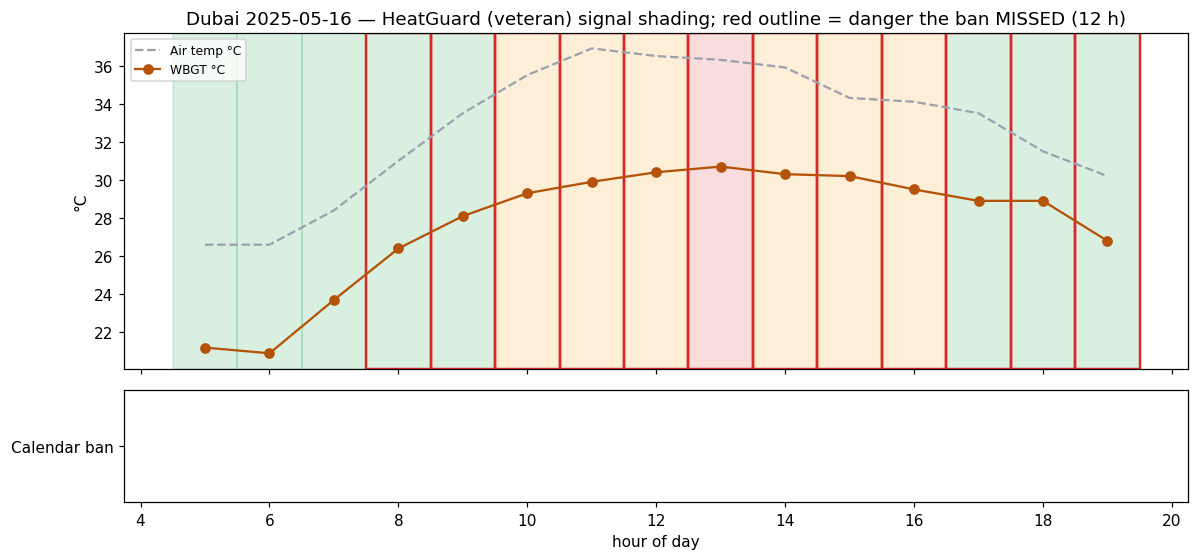

Ban: UAE: 12:30-15:00, 15 Jun - 15 Sep


In [3]:
def plot_day(site_key, worker="veteran"):
    demo = service.build_demo(site_key)
    tl = demo["timeline"]
    rows = tl["rows"]
    hours = [r["hour"] for r in rows]
    wbgt = [r["wbgt_c"] for r in rows]
    air = [r["tdb_c"] for r in rows]
    sig = [r[worker]["signal"] for r in rows]
    banned = [r["banned"] for r in rows]
    gap = [r["gap"] for r in rows]

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 5.2), height_ratios=[3, 1], sharex=True)
    ax0.plot(hours, air, "--", color="#9ca3af", label="Air temp °C")
    ax0.plot(hours, wbgt, "-o", color="#b45309", label="WBGT °C")
    for h, s in zip(hours, sig):
        ax0.axvspan(h - 0.5, h + 0.5, color=SIGNAL_COLOR[s], alpha=0.16)
    for h, g in zip(hours, gap):
        if g:
            ax0.axvspan(h - 0.5, h + 0.5, facecolor="none", edgecolor="#dc2626", lw=1.6)
    ax0.set_title(f"{demo['site']['name']} {tl['date']} — HeatGuard ({worker}) signal shading; "
                  f"red outline = danger the ban MISSED ({tl['gap_hours']} h)")
    ax0.set_ylabel("°C"); ax0.legend(loc="upper left", fontsize=8)

    ax1.broken_barh([(h - 0.5, 1) for h, b in zip(hours, banned) if b], (0, 1), color="#1f2937")
    ax1.set_yticks([0.5]); ax1.set_yticklabels(["Calendar ban"]); ax1.set_ylim(0, 1)
    ax1.set_xlabel("hour of day")
    plt.tight_layout(); plt.show()
    print(f"Ban: {demo['ban']['description']}")

plot_day("dubai", "veteran")

The Dubai focus day is in **May — before the 15 June ban begins** — so the calendar lane is empty
all day while HeatGuard is calling rest and stops. Now Riyadh in-season, viewed for the **new worker**:
the ban "protects" 12:00–15:00 but the unacclimatized newcomer is already in danger mid-morning.

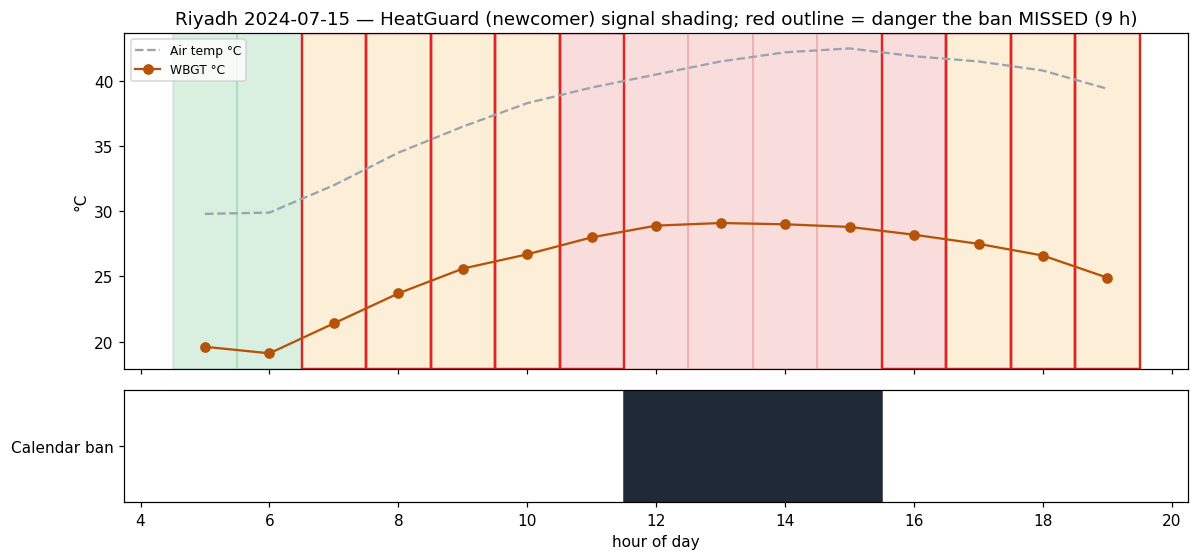

Ban: Saudi Arabia: 12:00-15:00, 15 Jun - 15 Sep


In [4]:
plot_day("riyadh", "newcomer")

## 3. Nicaragua back-test — the validity backbone

Our impact numbers rest on a real intervention. The model reproduces the documented La Isla /
Adelante outcomes (AKI −94%, productivity +10–20%) — a guard that fails loudly if an effect size
is ever altered.

In [5]:
bt = service.backtest()
print(f"reproduced AKI reduction : {bt['reproduced_aki_reduction']:.0%} (expected {bt['expected_aki_reduction']:.0%})")
print(f"productivity band        : {bt['productivity_band']} (expected {bt['expected_productivity_band']})")
print(f"PASSED                   : {bt['passed']}")
assert bt["passed"]

reproduced AKI reduction : 94% (expected 94%)
productivity band        : [0.1, 0.2] (expected [0.1, 0.2])
PASSED                   : True


## 4. Season impact projection

Applying the (coverage-scaled, mechanistic) effect sizes across the whole replayed season.

In [6]:
labels = ["dubai", "riyadh"]
imps = {k: service.season_impact(k, crew=100) for k in labels}
for k, imp in imps.items():
    print(f"\n{k.title()} (crew 100, {imp['season_days']} days):")
    print(f"  danger hours the ban MISSED      : {imp['danger_hours_caught_vs_ban']:,}  "
          f"(ban covered {imp['ban_coverage_pct']:.0f}% of danger)")
    print(f"  hours ban needlessly stopped work: {imp['ban_only_safe_hours']:,}")
    print(f"  AKI cases averted vs the ban     : {imp['aki_cases_averted_vs_ban']:.1f} "
          f"of {imp['aki_cases_baseline']:.0f} baseline")
    print(f"  cost per worker                  : ${imp['cost_per_worker_usd']:.0f}")


Dubai (crew 100, 138 days):
  danger hours the ban MISSED      : 1,237  (ban covered 18% of danger)
  hours ban needlessly stopped work: 0
  AKI cases averted vs the ban     : 7.7 of 10 baseline
  cost per worker                  : $95

Riyadh (crew 100, 107 days):
  danger hours the ban MISSED      : 97  (ban covered 62% of danger)
  hours ban needlessly stopped work: 214
  AKI cases averted vs the ban     : 3.6 of 10 baseline
  cost per worker                  : $95


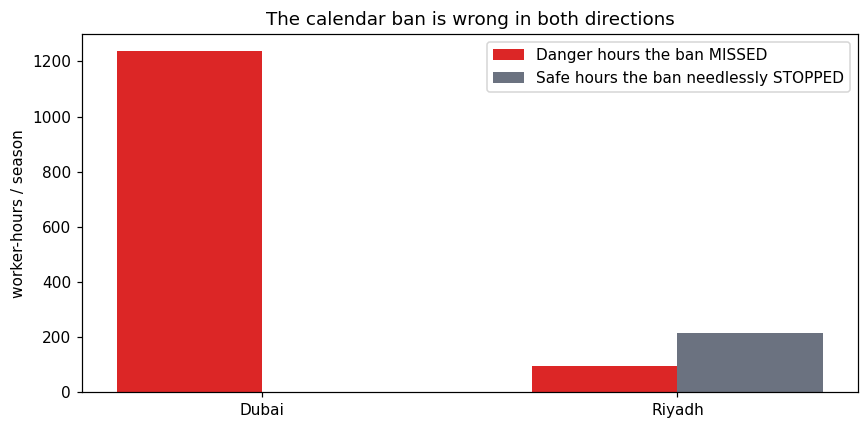

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels)); w = 0.35
caught = [imps[k]["danger_hours_caught_vs_ban"] for k in labels]
overrestrict = [imps[k]["ban_only_safe_hours"] for k in labels]
ax.bar(x - w/2, caught, w, label="Danger hours the ban MISSED", color="#dc2626")
ax.bar(x + w/2, overrestrict, w, label="Safe hours the ban needlessly STOPPED", color="#6b7280")
ax.set_xticks(x); ax.set_xticklabels([l.title() for l in labels])
ax.set_ylabel("worker-hours / season"); ax.set_title("The calendar ban is wrong in both directions")
ax.legend(); plt.tight_layout(); plt.show()

## 5. The business case — why a contractor switches it on

The intervention is *productivity-positive* and a *compliance shield*. Monetising the impact (all
assumptions conservative, labelled, and tunable in `data/economics.json`) gives the pitch its
headline ROI — deliberately computed on a conservative benefit subset (productivity + recovered safe
work + AKI averted + fines avoided), with death-risk and turnover reported separately.

Dubai  : ROI 3.3x-5.3x  payback ~41d  cost $9,500  headline benefit $31,765-$50,243


Riyadh : ROI 7.3x-10.4x  payback ~15d  cost $9,500  headline benefit $69,255-$99,080


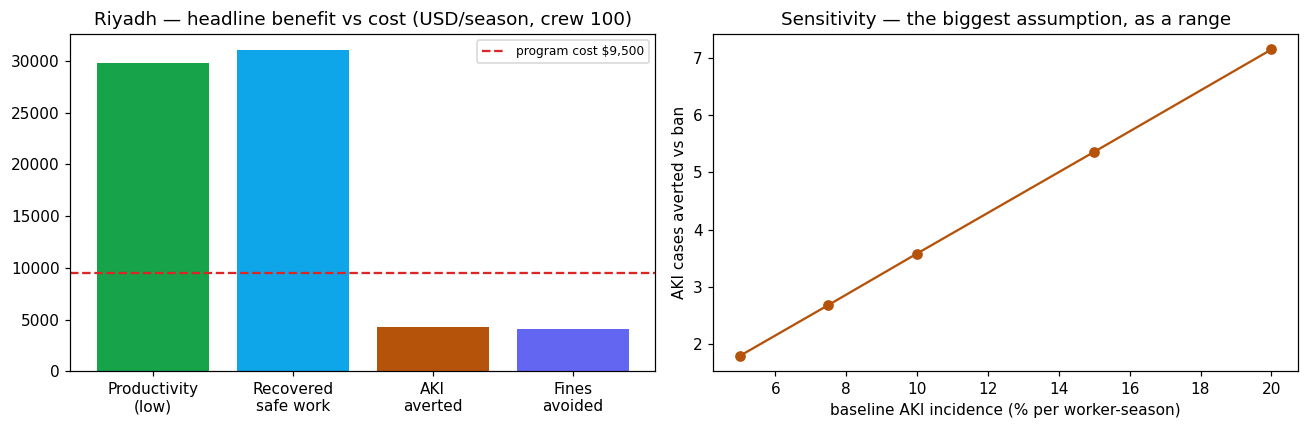

In [8]:
from heatguard import economics
for k in labels:
    rep = service.season_impact_report(k, crew=100)
    bc = economics.business_case(rep)
    print(f"{k.title():7s}: ROI {bc.roi_multiple_lo:.1f}x-{bc.roi_multiple_hi:.1f}x  "
          f"payback ~{bc.payback_days:.0f}d  cost ${bc.program_cost_usd:,.0f}  "
          f"headline benefit ${bc.headline_benefit_lo:,.0f}-${bc.headline_benefit_hi:,.0f}")

# benefit breakdown + AKI sensitivity for the focus site
rep = service.season_impact_report("riyadh", 100)
bc = economics.business_case(rep)
sens = service.impact_sensitivity("riyadh", 100)

fig, (axb, axs) = plt.subplots(1, 2, figsize=(12, 4))
items = ["Productivity\n(low)", "Recovered\nsafe work", "AKI\naverted", "Fines\navoided"]
vals = [bc.productivity_value_lo, bc.recovered_safe_work_value, bc.aki_value, bc.fines_avoided_value]
axb.bar(items, vals, color=["#16a34a", "#0ea5e9", "#b45309", "#6366f1"])
axb.axhline(bc.program_cost_usd, color="#dc2626", ls="--", label=f"program cost ${bc.program_cost_usd:,.0f}")
axb.set_title("Riyadh — headline benefit vs cost (USD/season, crew 100)"); axb.legend(fontsize=8)

inc = [s["baseline_aki_incidence"] * 100 for s in sens]
av = [s["aki_cases_averted_vs_ban"] for s in sens]
axs.plot(inc, av, "-o", color="#b45309")
axs.set_xlabel("baseline AKI incidence (% per worker-season)")
axs.set_ylabel("AKI cases averted vs ban")
axs.set_title("Sensitivity — the biggest assumption, as a range")
plt.tight_layout(); plt.show()

## 6. Honest limitations

- **WBGT estimation is approximate** without an on-site black-globe sensor (we use the validated
  Liljegren model from reanalysis, with a Stull fallback at night). The production system measures
  directly with a ~$300 meter — the engine already accepts a `measured` reading that bypasses estimation.
- **Effect sizes transfer** from Mesoamerican agriculture to Gulf construction with uncertainty;
  the baseline AKI incidence is a tunable assumption, surfaced in `impact.EffectSizes`.
- **Work intensity** is a supervisor input (light/moderate/heavy/very-heavy), per ISO 8996.
- The hard problem is **adoption**, which is why HeatGuard leads with the productivity and
  compliance-shield framing — the technology is the cheap, proven part.